### Time to get your hands dirty.  The transient Universe


Let's go back to our previous example on the astrophysical transient.


8) Fit the same model from before with the same priors,  but this time use nested sampling.

$y = b$, for $t<t_0$

$y = b + A\exp[-\alpha(t-t_0)]$, for $t\geq t_0$

Be careful with how you transform your parameter space into a unit hypercube for the nested sampling priors (I used `ppf` from `scipy.stats.uniform`, but there are other ways to do it)

An appropriate check on whether you have done things correctly is that the posterior samples you get from the burst analysis here should give an equivalent corner plot to the MCMC you did earlier.

7) Another possible model that may explain the data is a Gaussian profile described by:

$y = b + A\exp[-(t-t_0)^2 / 2\sigma_W^2]$

Fit this model usign nested sampling and reasonable priors (this time is up to you to decide...)

9) Unlike MCMCs, nested sampling provides the Bayesian evidence. Compute the Bayesian evidence for this Gaussian model, and for the original burst model. Which model is the favored description of the data? Express this in terms of the Jeffrey's scale.

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats 
import emcee
import pymc
import corner
import dynesty
from dynesty import plotting as dyplot
from dynesty import utils as dyfunc
import warnings
warnings.filterwarnings("ignore")

In [35]:
data = np.load("transient.npy")
time = data[:, 0]
flux = data[:, 1]
err = data[:, 2]

In [36]:
def burst_model(theta, time):
    A, b, alpha, t0 = theta
    y = np.zeros_like(time)
    y[time < t0] = b
    y[time >= t0] = b + A * np.exp(-alpha * (time[time >= t0] - t0))
    return y

In [37]:
def loglikelihood(theta, flux, time, err):
    return -0.5 * np.sum((flux-burst_model(theta, time))**2 / err**2) 

def prior_transform(u):
    A  = stats.uniform.ppf(u[0], 0, 50)
    b  = stats.uniform.ppf(u[1], 0, 50)
    log_alpha = stats.uniform.ppf(u[3], -5, 5)
    alpha  = np.exp(log_alpha)
    t0 = stats.uniform.ppf(u[2], 0, 100)
    return np.array([A, b, alpha, t0])

In [38]:
ndim = 4
sampler = dynesty.NestedSampler(loglikelihood, prior_transform, ndim, logl_args=(flux, time, err), nlive=300)
sampler.run_nested()
res = sampler.results

4529it [00:53, 84.35it/s, +300 | bound: 126 | nc: 1 | ncall: 67826 | eff(%):  7.151 | loglstar:   -inf < -48.763 <    inf | logz: -62.578 +/-  0.207 | dlogz:  0.001 >  0.309]


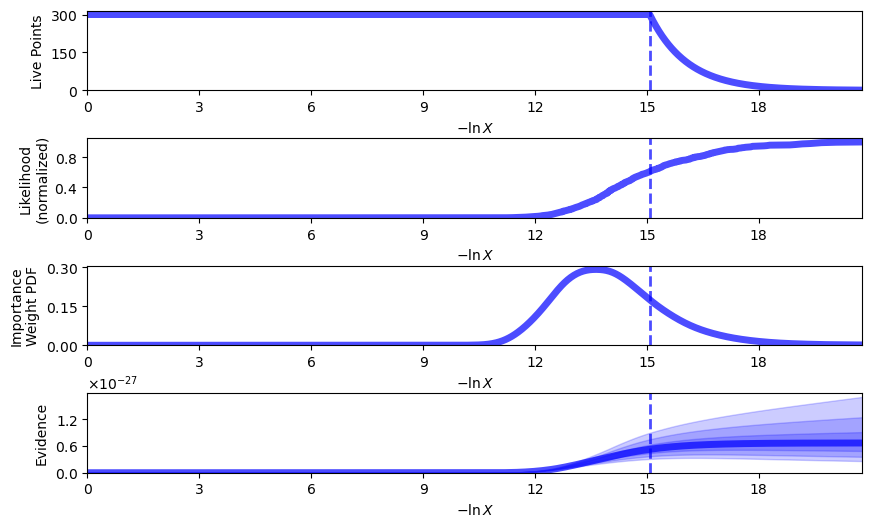

In [39]:
rfig, raxes = dyplot.runplot(res)
rfig.set_size_inches(10, 6)
rfig.subplots_adjust(hspace=0.6) # just so they don't overlap

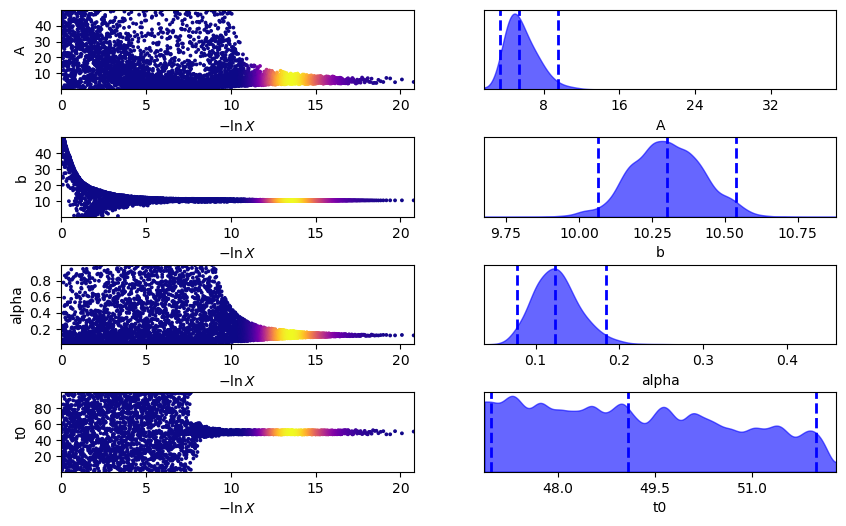

In [40]:
labels = ['A', 'b', 'alpha', 't0']
cfig, taxes = dyplot.traceplot(res, labels=labels)
cfig.set_size_inches(10, 6)
cfig.subplots_adjust(hspace=0.6) # just so they don't overlap

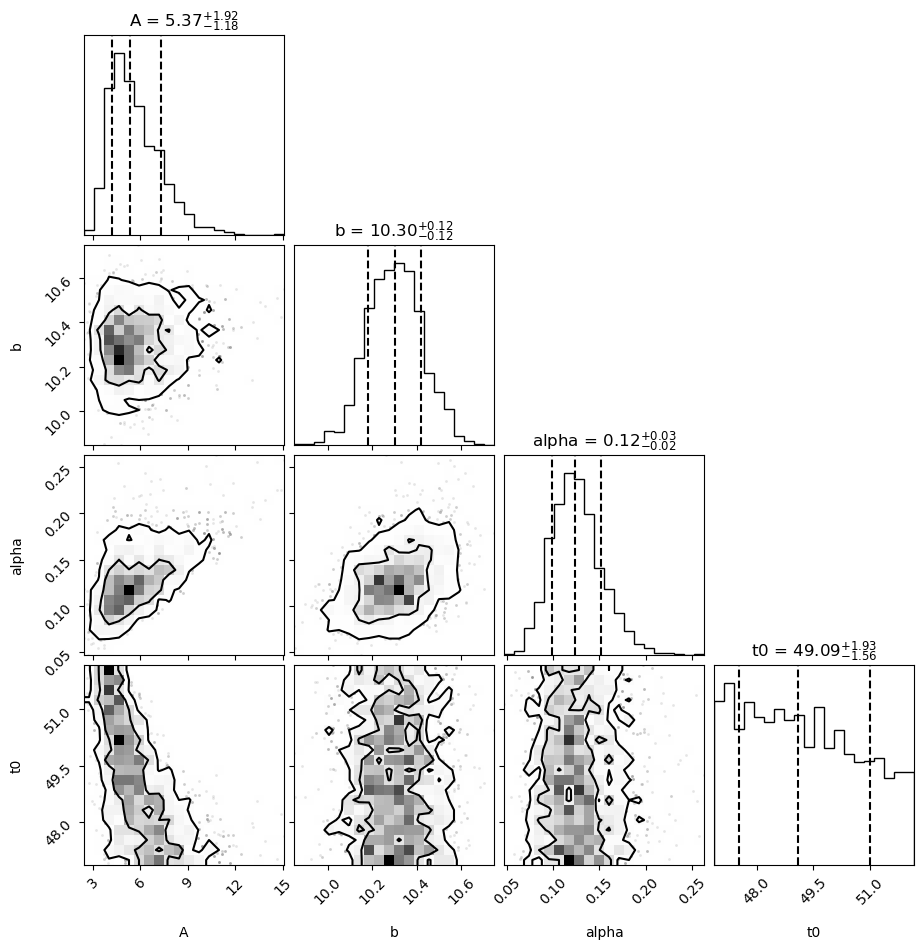

In [41]:
samples = res.samples
weights = np.exp(res.logwt - res.logz[-1])
burst_evidence = np.exp(res.logz[-1])

samples_new = dyfunc.resample_equal(samples, weights)

fig = corner.corner(samples_new, labels=labels, levels=[0.68,0.95], quantiles=[0.16, 0.5, 0.84], show_titles=True)
plt.show()

##### Gaussian model

$y = b + A\exp[-(t-t_0)^2 / 2\sigma_W^2]$

In [42]:
### QUALCOSA NON FUNZIONA PERCHè VIENE UNO SCHIFO IL CORNER PLOT

def gauss_model(theta, time):
    A, b, sigma, t0 = theta
    y = b + A * np.exp(-0.5 * ((time - t0) / sigma)**2)
    return y

In [ ]:
def loglikelihood(theta, flux, time, err):
    return -0.5 * np.sum((flux-gauss_model(theta, time))**2 / err**2) 

def prior_transform(u):
    A  = stats.uniform.ppf(u[0], 0, 50)
    b  = stats.uniform.ppf(u[1], 0, 50)
    log_sigma = stats.uniform.ppf(u[3], -2, 2)
    sigma = np.exp(log_sigma)
    t0 = stats.uniform.ppf(u[2], 0, 100)
    return np.array([A, b, sigma, t0])

In [44]:
ndim = 4
sampler = dynesty.NestedSampler(loglikelihood, prior_transform, ndim, logl_args=(flux, time, err), nlive=300)
sampler.run_nested()
res = sampler.results

5286it [01:37, 54.12it/s, +300 | bound: 240 | nc: 1 | ncall: 119340 | eff(%):  4.693 | loglstar:   -inf < -68.058 <    inf | logz: -84.471 +/-  0.227 | dlogz:  0.001 >  0.309]


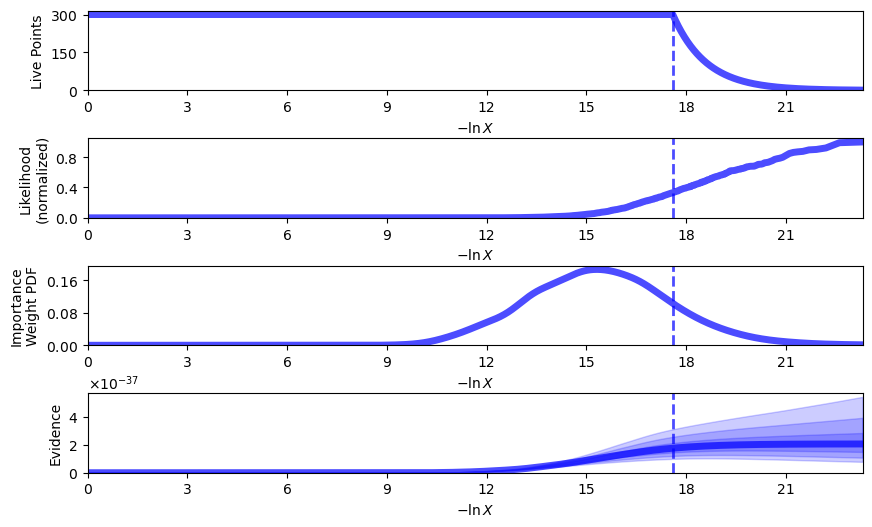

In [ ]:
rfig, raxes = dyplot.runplot(res)
rfig.set_size_inches(10, 6)
rfig.subplots_adjust(hspace=0.6) # just so they don't overlap

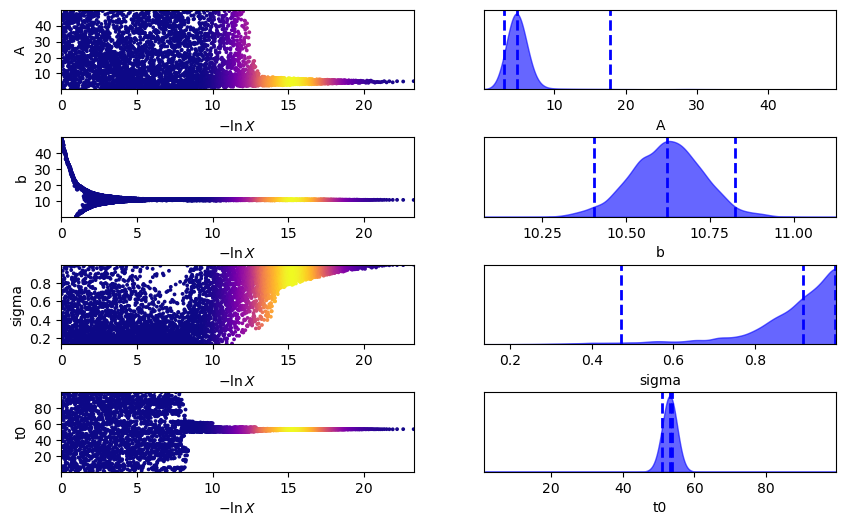

In [ ]:
labels_gauss = ['A', 'b', 'sigma', 't0']

cfig, taxes = dyplot.traceplot(res, labels=labels_gauss)
cfig.set_size_inches(10, 6)
cfig.subplots_adjust(hspace=0.6) # just so they don't overlap

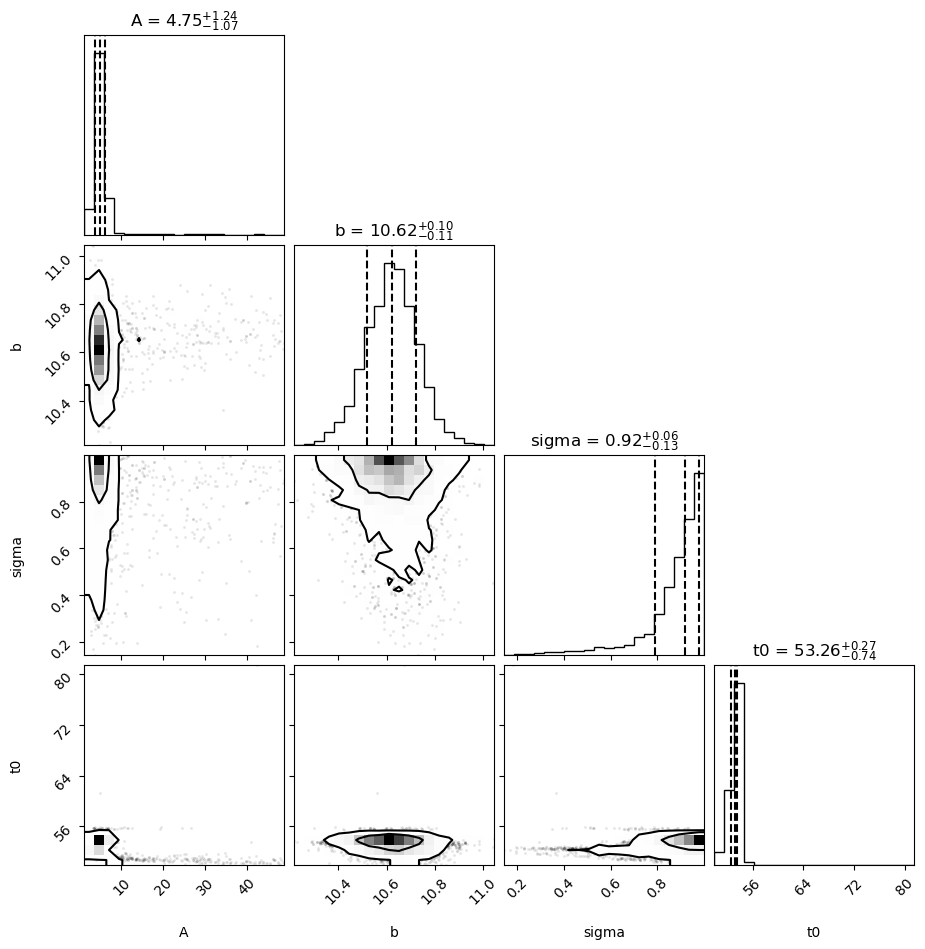

In [47]:
samples = res.samples
weights = np.exp(res.logwt - res.logz[-1])
gauss_evidence = np.exp(res.logz[-1])

samples_new = dyfunc.resample_equal(samples, weights)

fig = corner.corner(samples_new, labels=labels_gauss, levels=[0.68,0.95], quantiles=[0.16, 0.5, 0.84], show_titles=True)
plt.show()

In [48]:
B = burst_evidence / gauss_evidence
print(f"Burst vs Gaussian model Bayes factor: {B:.2f}")

Burst vs Gaussian model Bayes factor: 3222165769.47
